# Telco Customer Attrition Study

Exploratory analysis, feature engineering and Decision Tree modelling for the Telco customer churn dataset.
The trained pipeline is exported to `../artifacts/attrition_pipeline.pkl` and served by `server.py`.

Run the notebook from the `notebooks/` folder so the relative data and artifact paths resolve correctly.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib
import os
print(os.getcwd())

C:\Self\NAGP Assignments 2026\AbhishekJoshi_3153542_DS\notebooks


In [2]:
COLUMN_RENAMES = {
    "customerID": "client_id",
    "gender": "client_gender",
    "SeniorCitizen": "senior_flag",
    "Partner": "has_partner",
    "Dependents": "has_dependents",
    "tenure": "tenure_months",
    "PhoneService": "phone_line",
    "MultipleLines": "multi_line",
    "InternetService": "internet_plan",
    "OnlineSecurity": "security_addon",
    "OnlineBackup": "backup_addon",
    "DeviceProtection": "protection_addon",
    "TechSupport": "support_addon",
    "StreamingTV": "tv_streaming",
    "StreamingMovies": "movie_streaming",
    "Contract": "contract_term",
    "PaperlessBilling": "ebilling",
    "PaymentMethod": "payment_mode",
    "MonthlyCharges": "monthly_fee",
    "TotalCharges": "total_billed",
    "Churn": "attrition"
}

customers = pd.read_csv("../data/telco_customers.csv").rename(
    columns=COLUMN_RENAMES
)

In [3]:
customers.head()

,client_id,client_gender,senior_flag,has_partner,has_dependents,tenure_months,phone_line,multi_line,internet_plan,security_addon,...,protection_addon,support_addon,tv_streaming,movie_streaming,contract_term,ebilling,payment_mode,monthly_fee,total_billed,attrition
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
print("Number of rows:", customers.shape[0])
print("Number of columns:", customers.shape[1])

Number of rows: 7043
Number of columns: 21


In [5]:
customers.shape

(7043, 21)

In [6]:
print(customers.columns.tolist())

['client_id', 'client_gender', 'senior_flag', 'has_partner', 'has_dependents', 'tenure_months', 'phone_line', 'multi_line', 'internet_plan', 'security_addon', 'backup_addon', 'protection_addon', 'support_addon', 'tv_streaming', 'movie_streaming', 'contract_term', 'ebilling', 'payment_mode', 'monthly_fee', 'total_billed', 'attrition']


In [7]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   client_id         7043 non-null   object 
 1   client_gender     7043 non-null   object 
 2   senior_flag       7043 non-null   int64  
 3   has_partner       7043 non-null   object 
 4   has_dependents    7043 non-null   object 
 5   tenure_months     7043 non-null   int64  
 6   phone_line        7043 non-null   object 
 7   multi_line        7043 non-null   object 
 8   internet_plan     7043 non-null   object 
 9   security_addon    7043 non-null   object 
 10  backup_addon      7043 non-null   object 
 11  protection_addon  7043 non-null   object 
 12  support_addon     7043 non-null   object 
 13  tv_streaming      7043 non-null   object 
 14  movie_streaming   7043 non-null   object 
 15  contract_term     7043 non-null   object 
 16  ebilling          7043 non-null   object 


In [8]:
customers.isnull().sum()

client_id           0
client_gender       0
senior_flag         0
has_partner         0
has_dependents      0
tenure_months       0
phone_line          0
multi_line          0
internet_plan       0
security_addon      0
backup_addon        0
protection_addon    0
support_addon       0
tv_streaming        0
movie_streaming     0
contract_term       0
ebilling            0
payment_mode        0
monthly_fee         0
total_billed        0
attrition           0
dtype: int64

In [9]:
customers["total_billed"] = pd.to_numeric(
    customers["total_billed"],
    errors="coerce"
)

In [10]:
customers["total_billed"].dtype

dtype('float64')

In [11]:
customers.isnull().sum()

client_id            0
client_gender        0
senior_flag          0
has_partner          0
has_dependents       0
tenure_months        0
phone_line           0
multi_line           0
internet_plan        0
security_addon       0
backup_addon         0
protection_addon     0
support_addon        0
tv_streaming         0
movie_streaming      0
contract_term        0
ebilling             0
payment_mode         0
monthly_fee          0
total_billed        11
attrition            0
dtype: int64

In [12]:
print("Missing total_billed:",
      customers["total_billed"].isnull().sum())

Missing total_billed: 11


In [13]:
SimpleImputer(strategy="median")

,missing_values,nan
,strategy,'median'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [14]:
print("Duplicate rows:", customers.duplicated().sum())

Duplicate rows: 0


In [15]:
print("Duplicate customer IDs:",
      customers["client_id"].duplicated().sum())

Duplicate customer IDs: 0


In [16]:
customers.select_dtypes(include=["int64", "float64"]).columns

Index(['senior_flag', 'tenure_months', 'monthly_fee', 'total_billed'], dtype='object')

In [17]:
customers.select_dtypes(include=["object"]).columns

Index(['client_id', 'client_gender', 'has_partner', 'has_dependents',
       'phone_line', 'multi_line', 'internet_plan', 'security_addon',
       'backup_addon', 'protection_addon', 'support_addon', 'tv_streaming',
       'movie_streaming', 'contract_term', 'ebilling', 'payment_mode',
       'attrition'],
      dtype='object')

In [18]:
customers["attrition"].value_counts()

attrition
No     5174
Yes    1869
Name: count, dtype: int64

In [19]:
customers["attrition"].value_counts(normalize=True) * 100

attrition
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [20]:
print("Contract values:")
print(customers["contract_term"].unique())

Contract values:
['Month-to-month' 'One year' 'Two year']


In [21]:
print("Internet Service values:")
print(customers["internet_plan"].unique())

Internet Service values:
['DSL' 'Fiber optic' 'No']


In [22]:
print("Payment Method values:")
print(customers["payment_mode"].unique())

Payment Method values:
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


## Data Understanding - Key Observations

- The dataset contains 7,043 customer records and 21 columns.
- The target variable is `attrition`, which indicates whether a customer left the company.
- The dataset contains both numerical and categorical variables.
- No duplicate rows or duplicate customer IDs were identified.
- `total_billed` was initially stored as an object/string data type even though it represents a numerical value. It was converted to a numeric type, with invalid/blank values converted to missing values.
- 11 missing values were identified in `total_billed` after conversion.
- Approximately 73.5% of customers did not churn, while approximately 26.5% churned.
- The target variable is therefore moderately imbalanced.
- `client_id` is an identifier and should not be used as a predictive feature.

In [23]:
customers["total_billed"] = pd.to_numeric(
    customers["total_billed"],
    errors="coerce"
)

In [24]:
print(customers["total_billed"].dtype)
print("Missing total_billed:", customers["total_billed"].isnull().sum())

float64
Missing total_billed: 11


In [25]:
customers[customers["total_billed"].isnull()][
    ["client_id", "tenure_months", "monthly_fee", "total_billed", "attrition"]
]

,client_id,tenure_months,monthly_fee,total_billed,attrition
488,4472-LVYGI,0,52.55,NaN,No
753,3115-CZMZD,0,20.25,NaN,No
936,5709-LVOEQ,0,80.85,NaN,No
1082,4367-NUYAO,0,25.75,NaN,No
1340,1371-DWPAZ,0,56.05,NaN,No
3331,7644-OMVMY,0,19.85,NaN,No
3826,3213-VVOLG,0,25.35,NaN,No
4380,2520-SGTTA,0,20.00,NaN,No
5218,2923-ARZLG,0,19.70,NaN,No
6670,4075-WKNIU,0,73.35,NaN,No


In [26]:
customers["mean_monthly_fee"] = (
    customers["total_billed"] /
    customers["tenure_months"].replace(0, np.nan)
)

In [27]:
customers[
    ["tenure_months", "total_billed", "monthly_fee", "mean_monthly_fee"]
].head()

,tenure_months,total_billed,monthly_fee,mean_monthly_fee
0,1,29.85,29.85,29.850000
1,34,1889.50,56.95,55.573529
2,2,108.15,53.85,54.075000
3,45,1840.75,42.30,40.905556
4,2,151.65,70.70,75.825000


In [28]:
service_cols = [
    "phone_line",
    "multi_line",
    "security_addon",
    "backup_addon",
    "protection_addon",
    "support_addon",
    "tv_streaming",
    "movie_streaming"
]

In [29]:
customers["active_service_count"] = (
    customers[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

In [30]:
customers[
    ["client_id", "active_service_count", "attrition"]
].head()

,client_id,active_service_count,attrition
0,7590-VHVEG,1,No
1,5575-GNVDE,3,No
2,3668-QPYBK,3,Yes
3,7795-CFOCW,3,No
4,9237-HQITU,1,Yes


In [31]:
customers[["mean_monthly_fee", "active_service_count"]].describe()

,mean_monthly_fee,active_service_count
count,7032.000000,7043.000000
mean,64.799424,3.362914
std,30.185891,2.062031
min,13.775000,0.000000
25%,36.179891,1.000000
50%,70.373239,3.000000
75%,90.179560,5.000000
max,121.400000,8.000000


In [32]:
features = customers.drop(
    columns=["attrition", "client_id"]
)

target = customers["attrition"].map({
    "No": 0,
    "Yes": 1
})

In [33]:
print("Features shape:", features.shape)
print("Target shape:", target.shape)

Features shape: (7043, 21)
Target shape: (7043,)


In [34]:
print(target.value_counts())

attrition
0    5174
1    1869
Name: count, dtype: int64


In [35]:
features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.30,
    random_state=42,
    stratify=target
)

In [36]:
print("Training samples:", features_train.shape[0])
print("Testing samples:", features_test.shape[0])

Training samples: 4930
Testing samples: 2113


In [37]:
print("Training churn distribution:")
print(target_train.value_counts(normalize=True))

print("\nTesting churn distribution:")
print(target_test.value_counts(normalize=True))

Training churn distribution:
attrition
0    0.734686
1    0.265314
Name: proportion, dtype: float64

Testing churn distribution:
attrition
0    0.734501
1    0.265499
Name: proportion, dtype: float64


In [38]:
numeric_cols = [
    "senior_flag",
    "tenure_months",
    "monthly_fee",
    "total_billed",
    "mean_monthly_fee",
    "active_service_count"
]

In [39]:
category_cols = [
    "client_gender",
    "has_partner",
    "has_dependents",
    "phone_line",
    "multi_line",
    "internet_plan",
    "security_addon",
    "backup_addon",
    "protection_addon",
    "support_addon",
    "tv_streaming",
    "movie_streaming",
    "contract_term",
    "ebilling",
    "payment_mode"
]

In [40]:
numeric_branch = Pipeline(
    steps=[
        ("fill_missing", SimpleImputer(strategy="median"))
    ]
)

In [41]:
category_branch = Pipeline(
    steps=[
        (
            "fill_missing",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encode",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [42]:
column_processor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            numeric_branch,
            numeric_cols
        ),
        (
            "category",
            category_branch,
            category_cols
        )
    ]
)

## Data Preparation Summary

The dataset contains both numerical and categorical variables. The `client_id` column was excluded because it is an identifier and does not provide meaningful predictive information.

The `total_billed` column was converted from object to numeric format, with invalid or blank values converted to missing values.

Two additional features were created:
1. `mean_monthly_fee` — calculated from `total_billed / tenure_months`, providing an estimate of average customer spending.
2. `active_service_count` — counts the number of subscribed telecom services.

The target variable `attrition` was converted to binary values, where 0 represents no churn and 1 represents churn.

The dataset was divided into 70% training and 30% testing data using `random_state=42`. Stratified splitting was used to maintain the class distribution.

A preprocessing pipeline was designed to handle missing numerical values using median imputation and categorical variables using most-frequent imputation followed by one-hot encoding. The preprocessing will be fitted only on the training data to avoid data leakage.

In [43]:
CHURN_COLOR = "#E4572E"

sns.set_theme(
    style="ticks",
    palette=[
        "#2F6690",
        CHURN_COLOR,
        "#3A9E8F",
        "#F2A541",
        "#7768AE",
        "#5C677D"
    ],
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "--",
        "axes.titleweight": "bold",
        "axes.titlesize": 14,
        "axes.titlelocation": "left",
        "axes.labelcolor": "#33415C",
        "figure.dpi": 110
    }
)

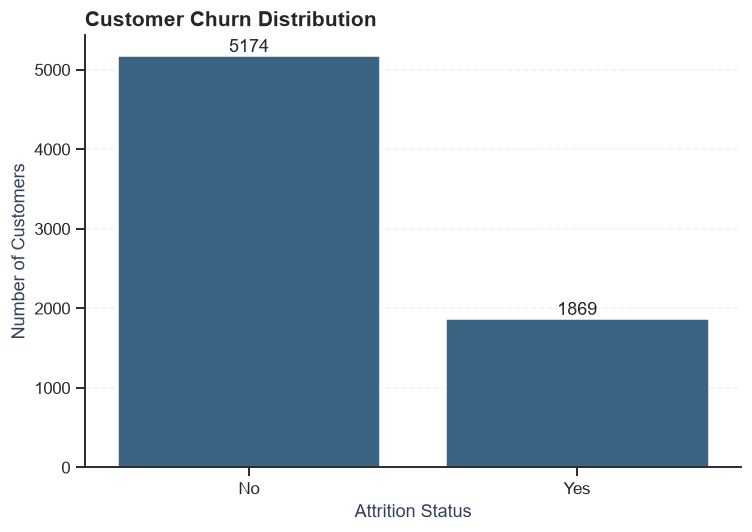

In [44]:
plt.figure(figsize=(7, 5))

chart_ax = sns.countplot(
    data=customers,
    x="attrition"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Attrition Status")
plt.ylabel("Number of Customers")

for bar_group in chart_ax.containers:
    chart_ax.bar_label(bar_group)

plt.tight_layout()
plt.show()

In [45]:
attrition_share = (
    customers["attrition"]
    .value_counts(normalize=True)
    .mul(100)
)

print(attrition_share)

attrition
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


### Business Insight

Approximately 73.5% of customers did not churn, while around 26.5% churned. 
This means that more than one in four customers in the dataset left the company.

Although the majority of customers were retained, the churn proportion is significant 
enough to justify proactive customer retention efforts.

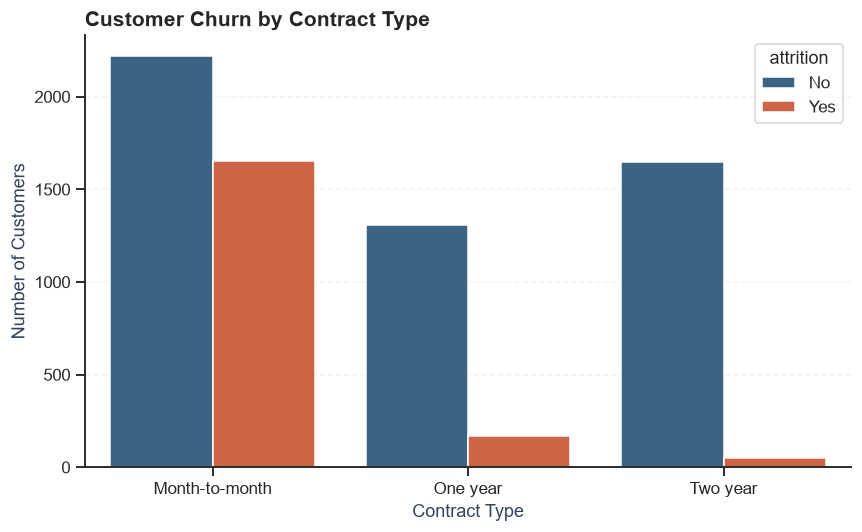

In [46]:
plt.figure(figsize=(8, 5))

chart_ax = sns.countplot(
    data=customers,
    x="contract_term",
    hue="attrition"
)

plt.title("Customer Churn by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [47]:
contract_attrition = pd.crosstab(
    customers["contract_term"],
    customers["attrition"],
    normalize="index"
) * 100

print(contract_attrition)

attrition              No        Yes
contract_term                       
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


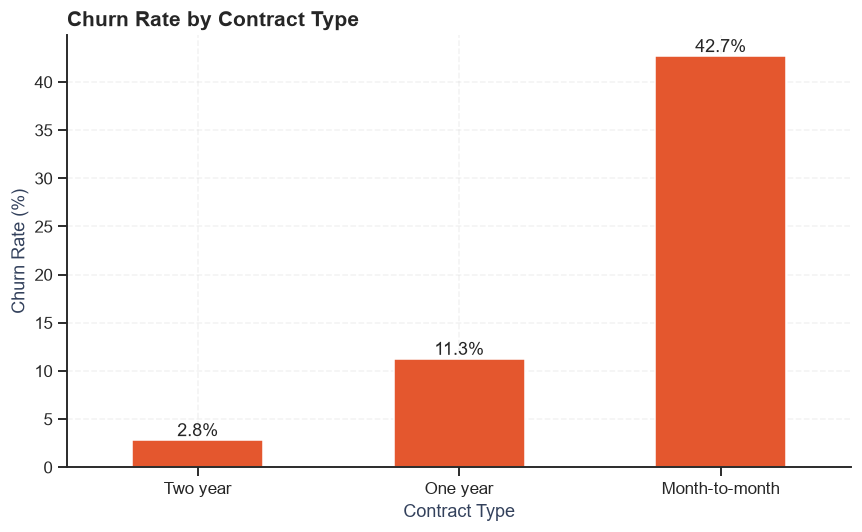

In [48]:
plt.figure(figsize=(8, 5))

chart_ax = contract_attrition["Yes"].sort_values().plot(
    kind="bar",
    color=CHURN_COLOR
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for bar_group in chart_ax.containers:
    chart_ax.bar_label(
        bar_group,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Business Insight

Contract type shows a strong relationship with customer churn. 
Month-to-month customers have a substantially higher churn rate than customers 
with one-year or two-year contracts.

This suggests that customers without long-term contractual commitment may be 
more likely to switch to competitors.

From a business perspective, the retention team could prioritize high-risk 
month-to-month customers and consider targeted incentives for longer-term 
contracts.

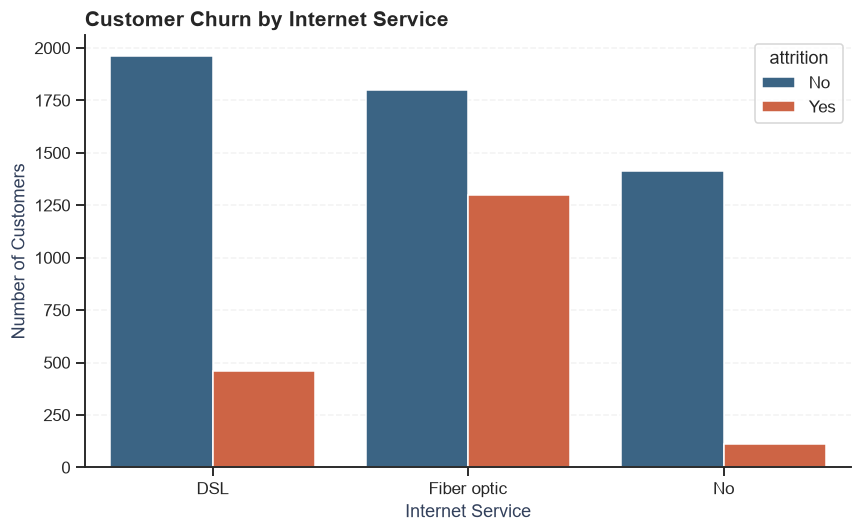

In [49]:
plt.figure(figsize=(8, 5))

chart_ax = sns.countplot(
    data=customers,
    x="internet_plan",
    hue="attrition"
)

plt.title("Customer Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [50]:
internet_attrition = pd.crosstab(
    customers["internet_plan"],
    customers["attrition"],
    normalize="index"
) * 100

print(internet_attrition)

attrition             No        Yes
internet_plan                      
DSL            81.040892  18.959108
Fiber optic    58.107235  41.892765
No             92.595020   7.404980


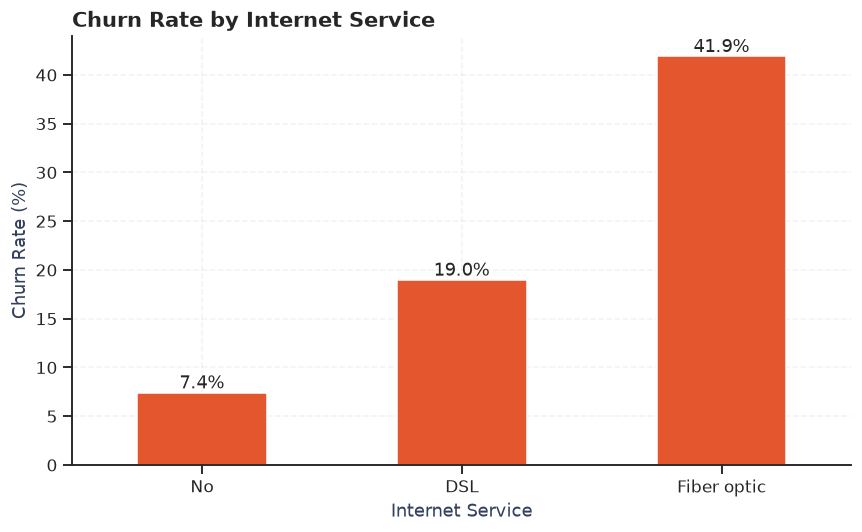

In [51]:
plt.figure(figsize=(8, 5))

chart_ax = internet_attrition["Yes"].sort_values().plot(
    kind="bar",
    color=CHURN_COLOR
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for bar_group in chart_ax.containers:
    chart_ax.bar_label(
        bar_group,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Business Insight

Internet service type is associated with customer churn. 
Fiber optic customers show a considerably higher churn rate than customers 
using DSL or customers without internet service.

This could indicate potential issues related to pricing, service quality, 
customer expectations, or competitive offerings.

The retention team should investigate fiber-optic customers more closely, 
particularly when they also have other high-risk characteristics.

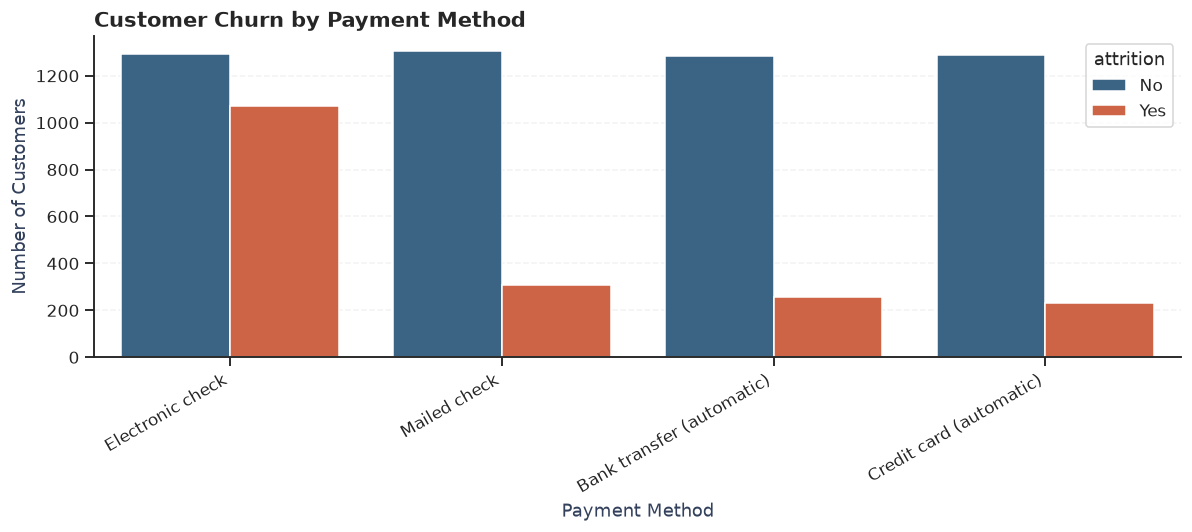

In [52]:
plt.figure(figsize=(11, 5))

chart_ax = sns.countplot(
    data=customers,
    x="payment_mode",
    hue="attrition"
)

plt.title("Customer Churn by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Customers")

plt.xticks(rotation=30, ha="right")

plt.tight_layout()
plt.show()

In [53]:
payment_attrition = pd.crosstab(
    customers["payment_mode"],
    customers["attrition"],
    normalize="index"
) * 100

print(payment_attrition)

attrition                         No        Yes
payment_mode                                   
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


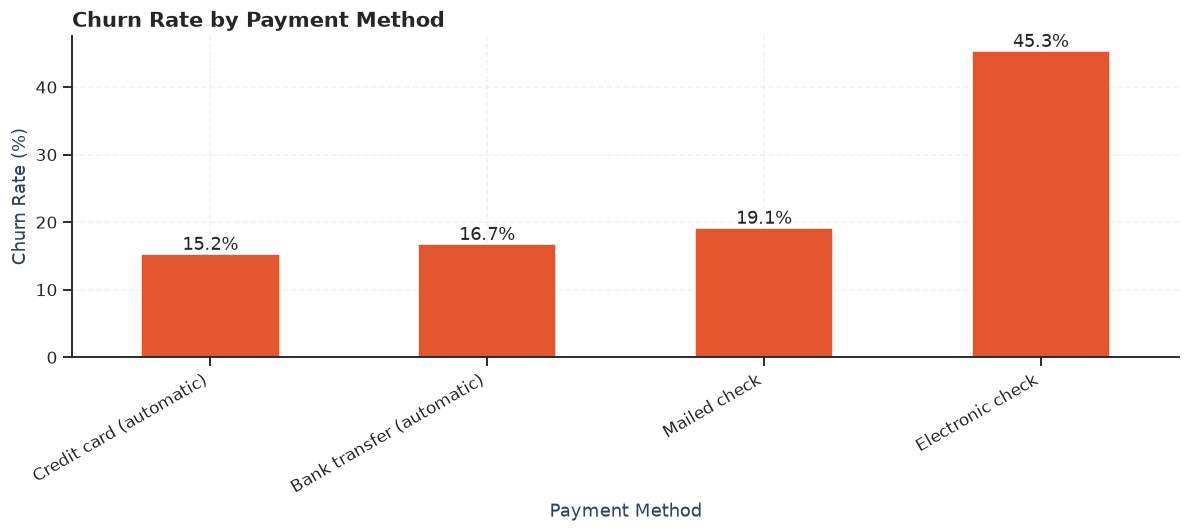

In [54]:
plt.figure(figsize=(11, 5))

chart_ax = payment_attrition["Yes"].sort_values().plot(
    kind="bar",
    color=CHURN_COLOR
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")

plt.xticks(rotation=30, ha="right")

for bar_group in chart_ax.containers:
    chart_ax.bar_label(
        bar_group,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Business Insight

Churn rates differ across payment methods. Customers using electronic check 
show a relatively high churn rate compared with several other payment methods.

Payment method may therefore be useful as a customer-risk indicator. 
The company could investigate whether customers using this payment method 
experience different billing, payment, or service experiences.

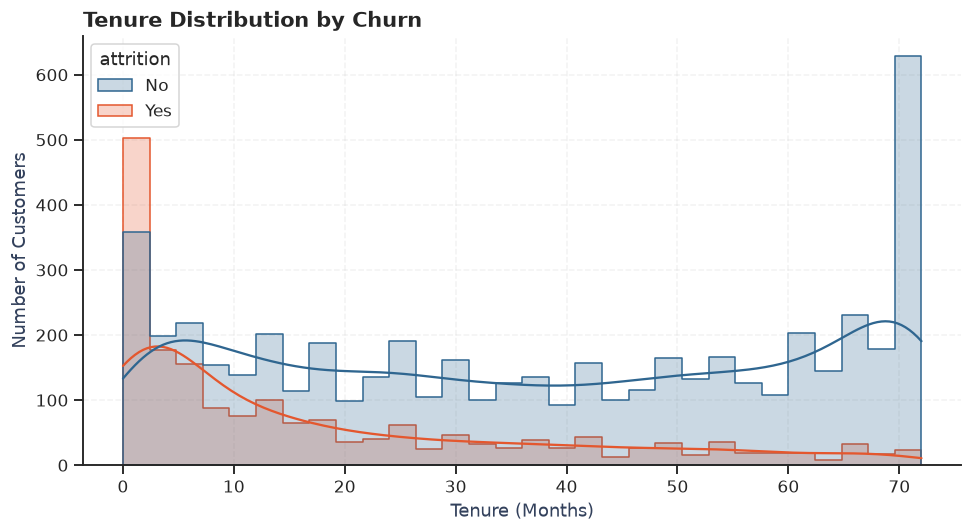

In [55]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=customers,
    x="tenure_months",
    hue="attrition",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Tenure Distribution by Churn")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

In [56]:
customers["tenure_band"] = pd.cut(
    customers["tenure_months"],
    bins=[0, 12, 24, 48, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-72 months"
    ],
    include_lowest=True
)

In [57]:
tenure_attrition = pd.crosstab(
    customers["tenure_band"],
    customers["attrition"],
    normalize="index"
) * 100

print(tenure_attrition)

attrition            No        Yes
tenure_band                       
0-12 months   52.561757  47.438243
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-72 months  90.486824   9.513176


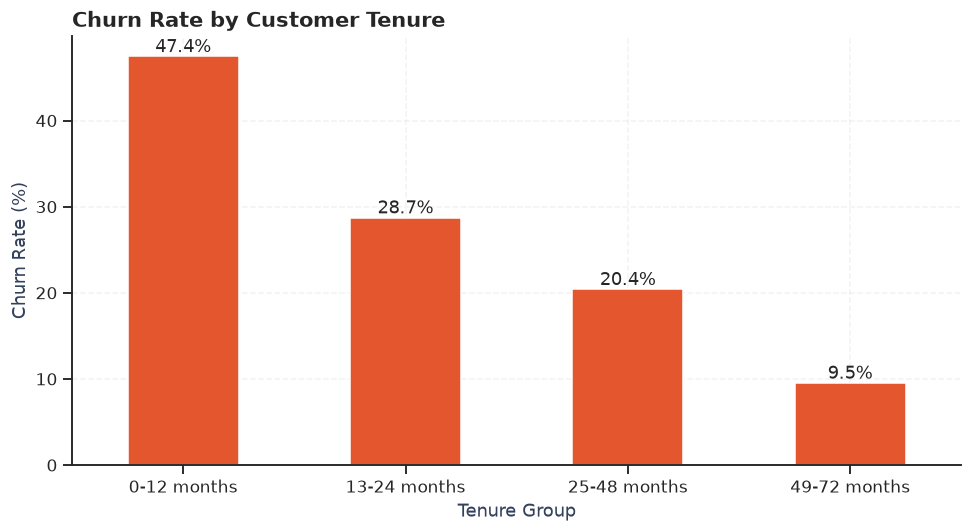

In [58]:
plt.figure(figsize=(9, 5))

chart_ax = tenure_attrition["Yes"].plot(
    kind="bar",
    color=CHURN_COLOR
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)

for bar_group in chart_ax.containers:
    chart_ax.bar_label(
        bar_group,
        fmt="%.1f%%"
    )

plt.tight_layout()
plt.show()

### Business Insight

Customer tenure shows a strong relationship with churn. 
Customers in the early stages of their relationship with the company 
have a higher churn rate than customers who have stayed for longer periods.

This suggests that the early customer lifecycle is an important retention 
window. The company could introduce stronger onboarding, customer support, 
and engagement programs during the first year.

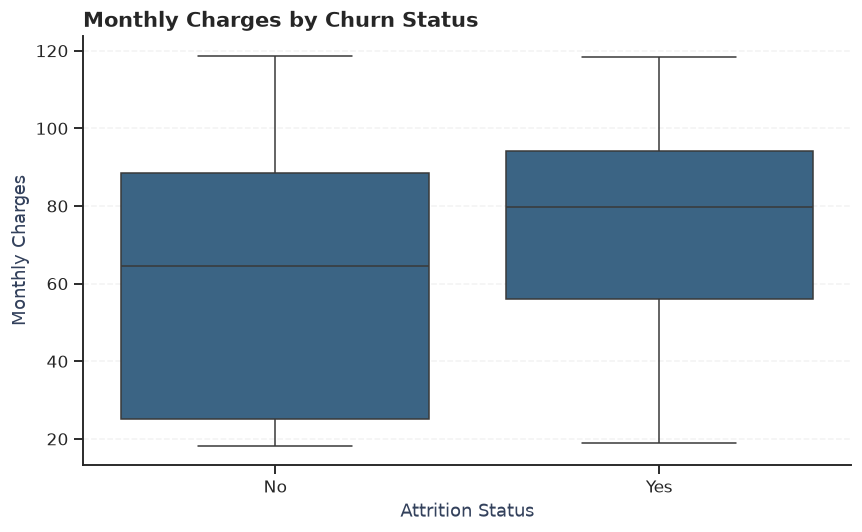

In [59]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=customers,
    x="attrition",
    y="monthly_fee"
)

plt.title("Monthly Charges by Churn Status")
plt.xlabel("Attrition Status")
plt.ylabel("Monthly Charges")

plt.tight_layout()
plt.show()

### Business Insight

Monthly charges show a noticeable difference between churned and retained 
customers. Churned customers tend to have higher monthly charges.

Higher monthly charges may therefore be an important risk indicator, 
particularly when combined with other characteristics such as month-to-month 
contracts or short tenure.

The company could investigate whether high charges are perceived as poor 
value by customers.

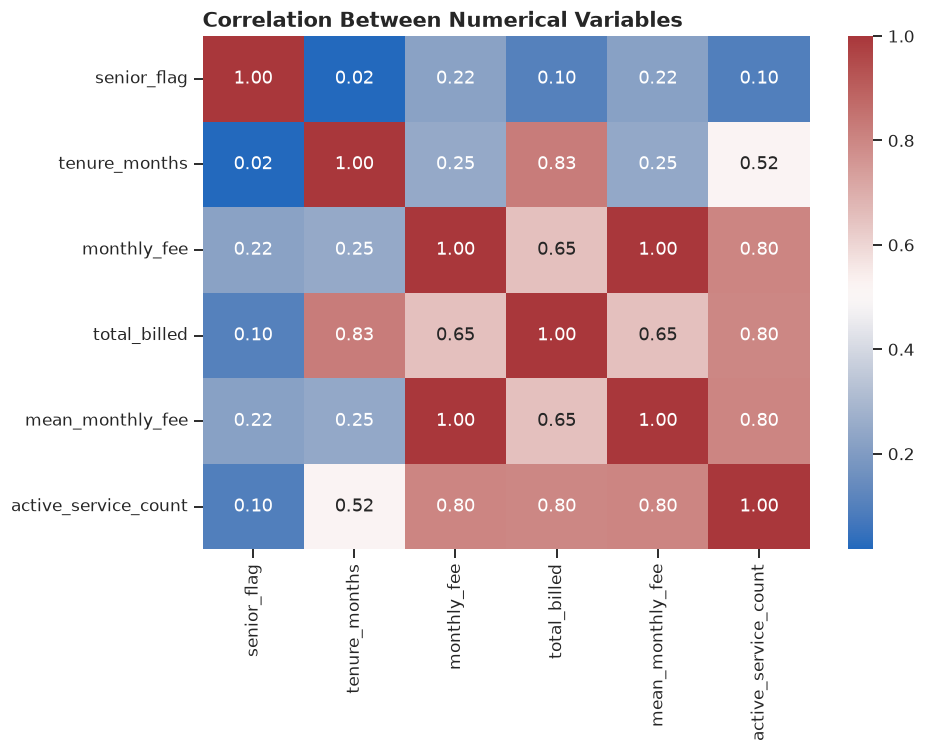

In [60]:
corr_columns = [
    "senior_flag",
    "tenure_months",
    "monthly_fee",
    "total_billed",
    "mean_monthly_fee",
    "active_service_count"
]

corr_matrix = customers[corr_columns].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag"
)

plt.title("Correlation Between Numerical Variables")

plt.tight_layout()
plt.show()

# EDA Summary

The exploratory analysis identified several important patterns associated with customer churn:

1. Approximately 26.5% of customers in the dataset churned, while 73.5% remained with the company.

2. Contract type is strongly associated with churn. Month-to-month customers show substantially higher churn than customers with one-year or two-year contracts.

3. Internet service type is associated with churn. Fiber optic customers show a relatively high churn rate compared with other internet service groups.

4. Churn rates differ across payment methods, with electronic check customers showing a relatively high churn rate.

5. Customer tenure is associated with churn. Customers with shorter tenure have higher churn rates, suggesting that the early customer lifecycle is an important retention period.

6. Monthly charges also show differences between churned and retained customers, with churned customers generally having higher monthly charges.

These observations suggest that contract type, internet service, payment method, tenure, and monthly charges may be useful predictors of customer churn. These relationships will be further evaluated using the machine-learning model.

In [61]:
customers["mean_monthly_fee"] = (
    customers["total_billed"] /
    customers["tenure_months"].replace(0, np.nan)
)

In [62]:
customers[[
    "tenure_months",
    "total_billed",
    "mean_monthly_fee",
    "attrition"
]].head(10)

,tenure_months,total_billed,mean_monthly_fee,attrition
0,1,29.85,29.850000,No
1,34,1889.50,55.573529,No
2,2,108.15,54.075000,Yes
3,45,1840.75,40.905556,No
4,2,151.65,75.825000,Yes
5,8,820.50,102.562500,Yes
6,22,1949.40,88.609091,No
7,10,301.90,30.190000,No
8,28,3046.05,108.787500,Yes
9,62,3487.95,56.257258,No


In [63]:
customers["mean_monthly_fee"].describe()

count    7032.000000
mean       64.799424
std        30.185891
min        13.775000
25%        36.179891
50%        70.373239
75%        90.179560
max       121.400000
Name: mean_monthly_fee, dtype: float64

In [64]:
service_cols = [
    "phone_line",
    "multi_line",
    "security_addon",
    "backup_addon",
    "protection_addon",
    "support_addon",
    "tv_streaming",
    "movie_streaming"
]

customers["active_service_count"] = (
    customers[service_cols]
    .eq("Yes")
    .sum(axis=1)
)

In [65]:
customers.groupby("attrition")[[
    "mean_monthly_fee",
    "active_service_count"
]].mean()

,mean_monthly_fee,active_service_count
attrition,,
No,61.312024,3.446270
Yes,74.433154,3.132156


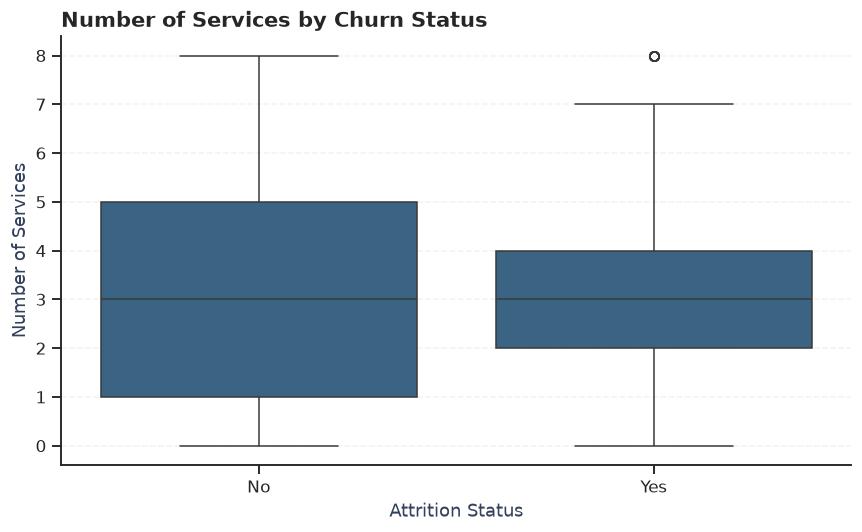

In [66]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=customers,
    x="attrition",
    y="active_service_count"
)

plt.title("Number of Services by Churn Status")
plt.xlabel("Attrition Status")
plt.ylabel("Number of Services")

plt.tight_layout()
plt.show()

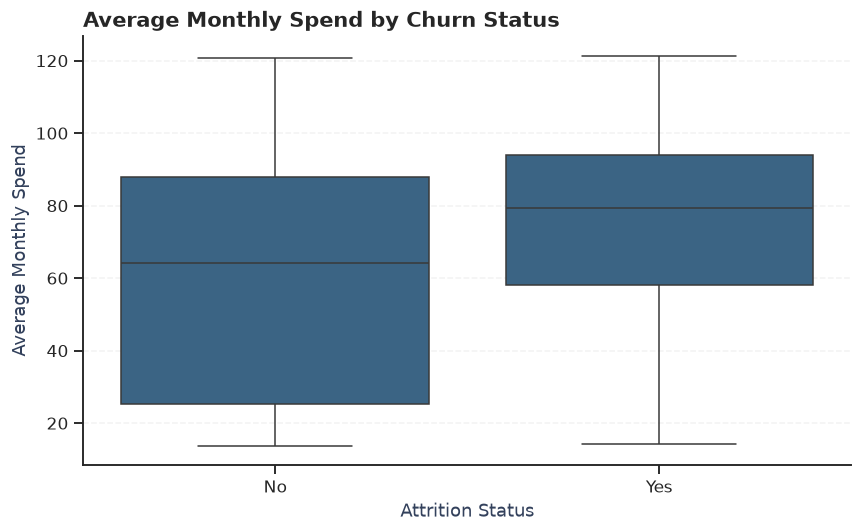

In [67]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=customers,
    x="attrition",
    y="mean_monthly_fee"
)

plt.title("Average Monthly Spend by Churn Status")
plt.xlabel("Attrition Status")
plt.ylabel("Average Monthly Spend")

plt.tight_layout()
plt.show()

# Feature Engineering

## Feature 1: mean_monthly_fee

`mean_monthly_fee` was created by dividing `total_billed` by customer `tenure_months`.
Customers with zero tenure were treated as missing for this calculation to avoid
division by zero.

This feature provides an estimate of the customer's average monthly spending
over their relationship with the company. It may help identify spending
patterns associated with churn.

## Feature 2: active_service_count

`active_service_count` was created by counting the number of subscribed services marked
as "Yes" across the phone, multiple-lines, security, backup, device protection,
technical support, and streaming service variables.

This feature summarizes the breadth of services used by a customer. Customers
with different levels of service adoption may have different churn behavior,
making this potentially useful for prediction.

In [68]:
shallow_pipeline = Pipeline(
    steps=[
        ("column_processor", column_processor),
        (
            "tree_stage",
            DecisionTreeClassifier(
                max_depth=4,
                random_state=42
            )
        )
    ]
)

In [69]:
shallow_pipeline.fit(features_train, target_train)

,steps,"[('column_processor', ...), ('tree_stage', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('category', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [70]:
shallow_pred = shallow_pipeline.predict(features_test)

In [71]:
shallow_proba = shallow_pipeline.predict_proba(features_test)[:, 1]

In [72]:
def report_scores(actual, predicted):
    acc = accuracy_score(actual, predicted)
    prec = precision_score(actual, predicted)
    rec = recall_score(actual, predicted)
    f1_val = f1_score(actual, predicted)

    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1 Score : {f1_val:.4f}")

In [73]:
print("Model 1 - Decision Tree (max_depth=4)")
report_scores(target_test, shallow_pred)

Model 1 - Decision Tree (max_depth=4)
Accuracy : 0.7918
Precision: 0.6580
Recall   : 0.4492
F1 Score : 0.5339


In [74]:
deep_pipeline = Pipeline(
    steps=[
        ("column_processor", column_processor),
        (
            "tree_stage",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=10,
                random_state=42
            )
        )
    ]
)

In [75]:
deep_pipeline.fit(features_train, target_train)

,steps,"[('column_processor', ...), ('tree_stage', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('numeric', ...), ('category', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [76]:
deep_pred = deep_pipeline.predict(features_test)

In [77]:
deep_proba = deep_pipeline.predict_proba(features_test)[:, 1]

In [78]:
print("Model 2 - Decision Tree (max_depth=8)")
report_scores(target_test, deep_pred)

Model 2 - Decision Tree (max_depth=8)
Accuracy : 0.7799
Precision: 0.6004
Recall   : 0.5116
F1 Score : 0.5525


In [79]:
comparison_table = pd.DataFrame({
    "Model": [
        "Decision Tree - Depth 4",
        "Decision Tree - Depth 8"
    ],
    "Accuracy": [
        accuracy_score(target_test, shallow_pred),
        accuracy_score(target_test, deep_pred)
    ],
    "Precision": [
        precision_score(target_test, shallow_pred),
        precision_score(target_test, deep_pred)
    ],
    "Recall": [
        recall_score(target_test, shallow_pred),
        recall_score(target_test, deep_pred)
    ],
    "F1 Score": [
        f1_score(target_test, shallow_pred),
        f1_score(target_test, deep_pred)
    ]
})

comparison_table

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree - Depth 4,0.791765,0.657963,0.449198,0.533898
1,Decision Tree - Depth 8,0.779934,0.600418,0.511586,0.552454


## Model Selection

Two Decision Tree configurations were evaluated.

The first model, with a maximum depth of 4, achieved an accuracy of 79.18%,
precision of 65.80%, recall of 44.92%, and F1 score of 53.39%.

The second model, with a maximum depth of 8 and minimum 10 samples per leaf,
achieved an accuracy of 77.99%, precision of 60.04%, recall of 51.16%, and
F1 score of 55.25%.

Although Model 1 achieved slightly higher accuracy and precision, Model 2
achieved higher recall and F1 score. Since the business objective is to
identify customers who are likely to churn, recall is particularly important.
A false negative represents a customer who actually churns but was not
identified by the model.

Therefore, Model 2 was selected as the final model because it identifies a
larger proportion of actual churners and provides a better balance between
precision and recall, as reflected by its higher F1 score.

### Precision vs Recall for Churn Prediction

For a telecom company whose objective is to proactively identify customers
who may churn, Recall is generally more important than Precision.

A false negative means that a customer who is actually going to churn is not
identified by the model. This represents a missed opportunity for the retention
team to intervene.

A false positive means that a customer is incorrectly identified as a churn
risk. Although this may result in some unnecessary retention efforts, the
business may still be able to tolerate this if the cost of contacting the
customer is relatively low.

Therefore, the final model should give significant consideration to Recall,
while also maintaining reasonable Precision and F1 Score.

In [80]:
conf_matrix = confusion_matrix(target_test, deep_pred)

print(conf_matrix)

[[1361  191]
 [ 274  287]]


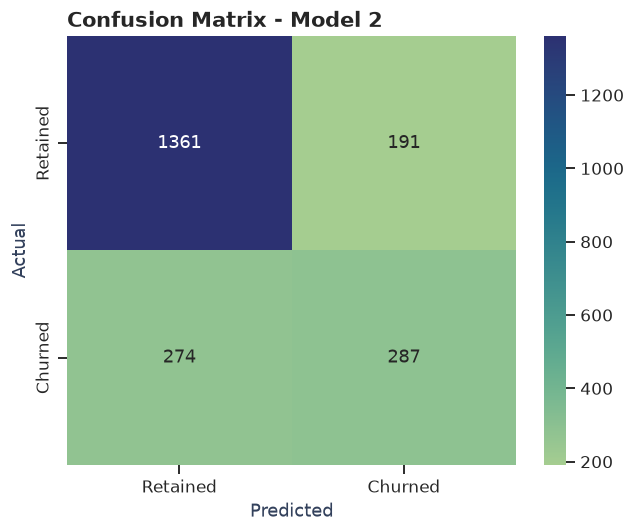

In [81]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="crest",
    xticklabels=["Retained", "Churned"],
    yticklabels=["Retained", "Churned"]
)

plt.title("Confusion Matrix - Model 2")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()
plt.show()

In [82]:
print(
    classification_report(
        target_test,
        deep_pred,
        target_names=["Retained", "Churned"]
    )
)

              precision    recall  f1-score   support

    Retained       0.83      0.88      0.85      1552
     Churned       0.60      0.51      0.55       561

    accuracy                           0.78      2113
   macro avg       0.72      0.69      0.70      2113
weighted avg       0.77      0.78      0.77      2113



# Model Comparison

Two Decision Tree configurations were evaluated.

### Model 1
- Maximum tree depth: 4
- Random state: 42

### Model 2
- Maximum tree depth: 8
- Minimum samples per leaf: 10
- Random state: 42

The models were compared using Accuracy, Precision, Recall, and F1 Score.

Because the business objective is to identify customers who are likely to
churn, Recall is particularly important. A false negative represents a
customer who is likely to churn but was not identified by the model.

The final model will therefore be selected by considering Recall together
with Precision, F1 Score, and overall model stability rather than relying
only on Accuracy.

In [83]:
encoded_names = (
    deep_pipeline
    .named_steps["column_processor"]
    .get_feature_names_out()
)

In [84]:
importance_values = (
    deep_pipeline
    .named_steps["tree_stage"]
    .feature_importances_
)

In [85]:
importance_table = pd.DataFrame({
    "Feature": encoded_names,
    "Importance": importance_values
})

In [86]:
importance_table = importance_table.sort_values(
    by="Importance",
    ascending=False
)

In [87]:
importance_table.head(15)

,Feature,Importance
38,category__contract_term_Month-to-month,0.395067
1,numeric__tenure_months,0.158915
18,category__internet_plan_Fiber optic,0.118066
4,numeric__mean_monthly_fee,0.060017
2,numeric__monthly_fee,0.054838
3,numeric__total_billed,0.043670
45,category__payment_mode_Electronic check,0.024698
29,category__support_addon_No,0.021008
23,category__backup_addon_No,0.011765
14,category__multi_line_No,0.011585


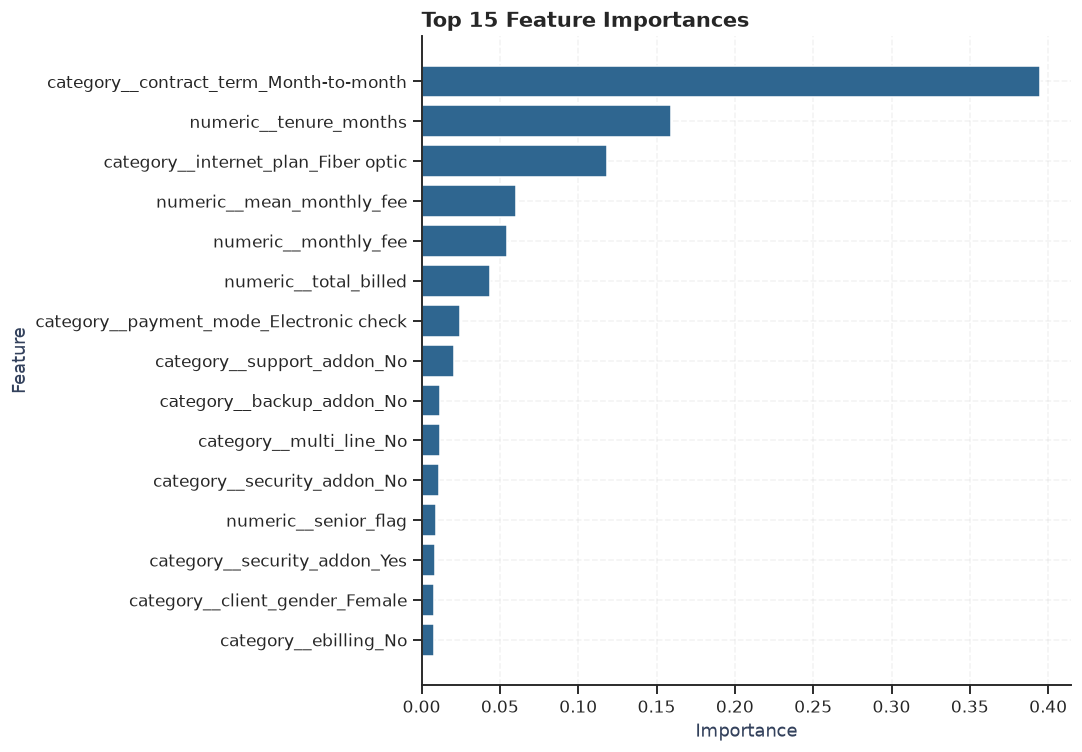

In [88]:
top_importances = importance_table.head(15).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_importances["Feature"],
    top_importances["Importance"]
)

plt.title("Top 15 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## Feature Importance Analysis

The feature importance analysis of the final Decision Tree identified
contract_term_Month-to-month as the most important predictive feature, with an
importance of approximately 0.395.

The next most important features were tenure_months (0.159) and
Fiber optic internet service (0.118). Other relevant predictors included
mean_monthly_fee, monthly_fee, total_billed, electronic check payment
method, and lack of technical support.

These findings are consistent with the exploratory data analysis, where
contract type, tenure, internet service, and monthly charges showed
noticeable relationships with customer churn.

Feature importance should be interpreted as the contribution of a feature
to the trained model's predictions rather than evidence of causation.
Therefore, these variables should be considered important churn indicators
rather than direct causes of churn.

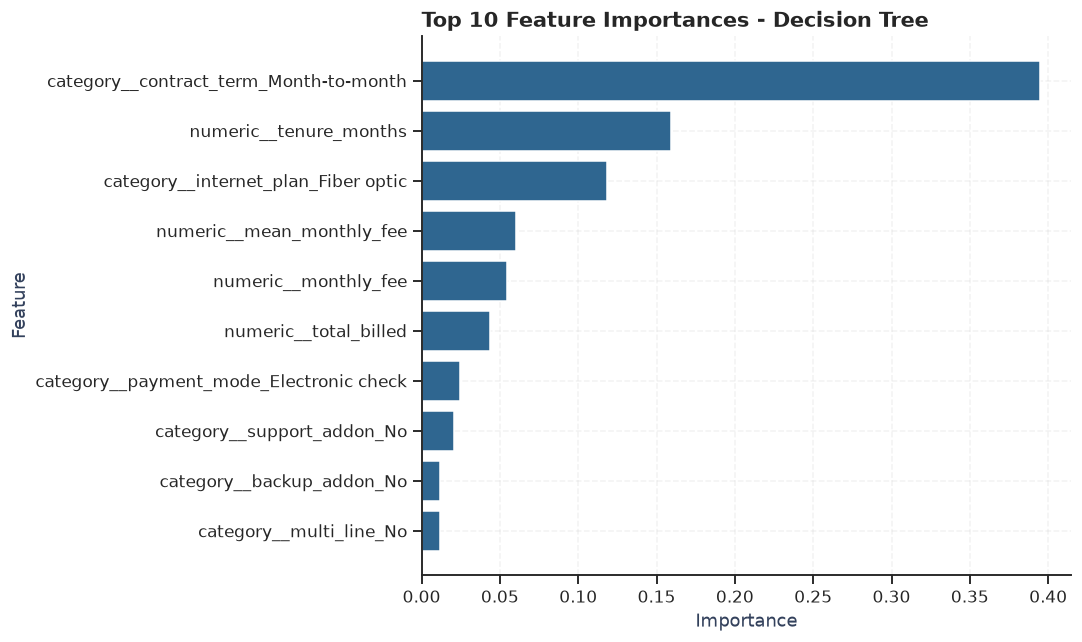

In [89]:
top_importances = importance_table.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_importances["Feature"],
    top_importances["Importance"]
)

plt.title("Top 10 Feature Importances - Decision Tree")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# Model Evaluation

The final Decision Tree model achieved an accuracy of 77.99% on the test
dataset.

For the churn class, the model achieved:
- Precision: 60.04%
- Recall: 51.16%
- F1 Score: 55.25%

The confusion matrix contained 1,361 true negatives, 191 false positives,
274 false negatives, and 287 true positives.

The model correctly identified 287 of the 561 customers who actually
churned. This corresponds to a recall of approximately 51%.

Recall is particularly important for this business problem because a false
negative represents a customer who churns but was not identified by the
model. Such a customer represents a missed opportunity for proactive
retention.

The model nevertheless produces false positives, meaning some customers
predicted as churn risks will not actually churn. This is a reasonable
trade-off if the cost of contacting a potential churn customer is lower
than the cost of losing an existing customer.

In [90]:
from sklearn.tree import plot_tree

In [91]:
tree_estimator = deep_pipeline.named_steps["tree_stage"]

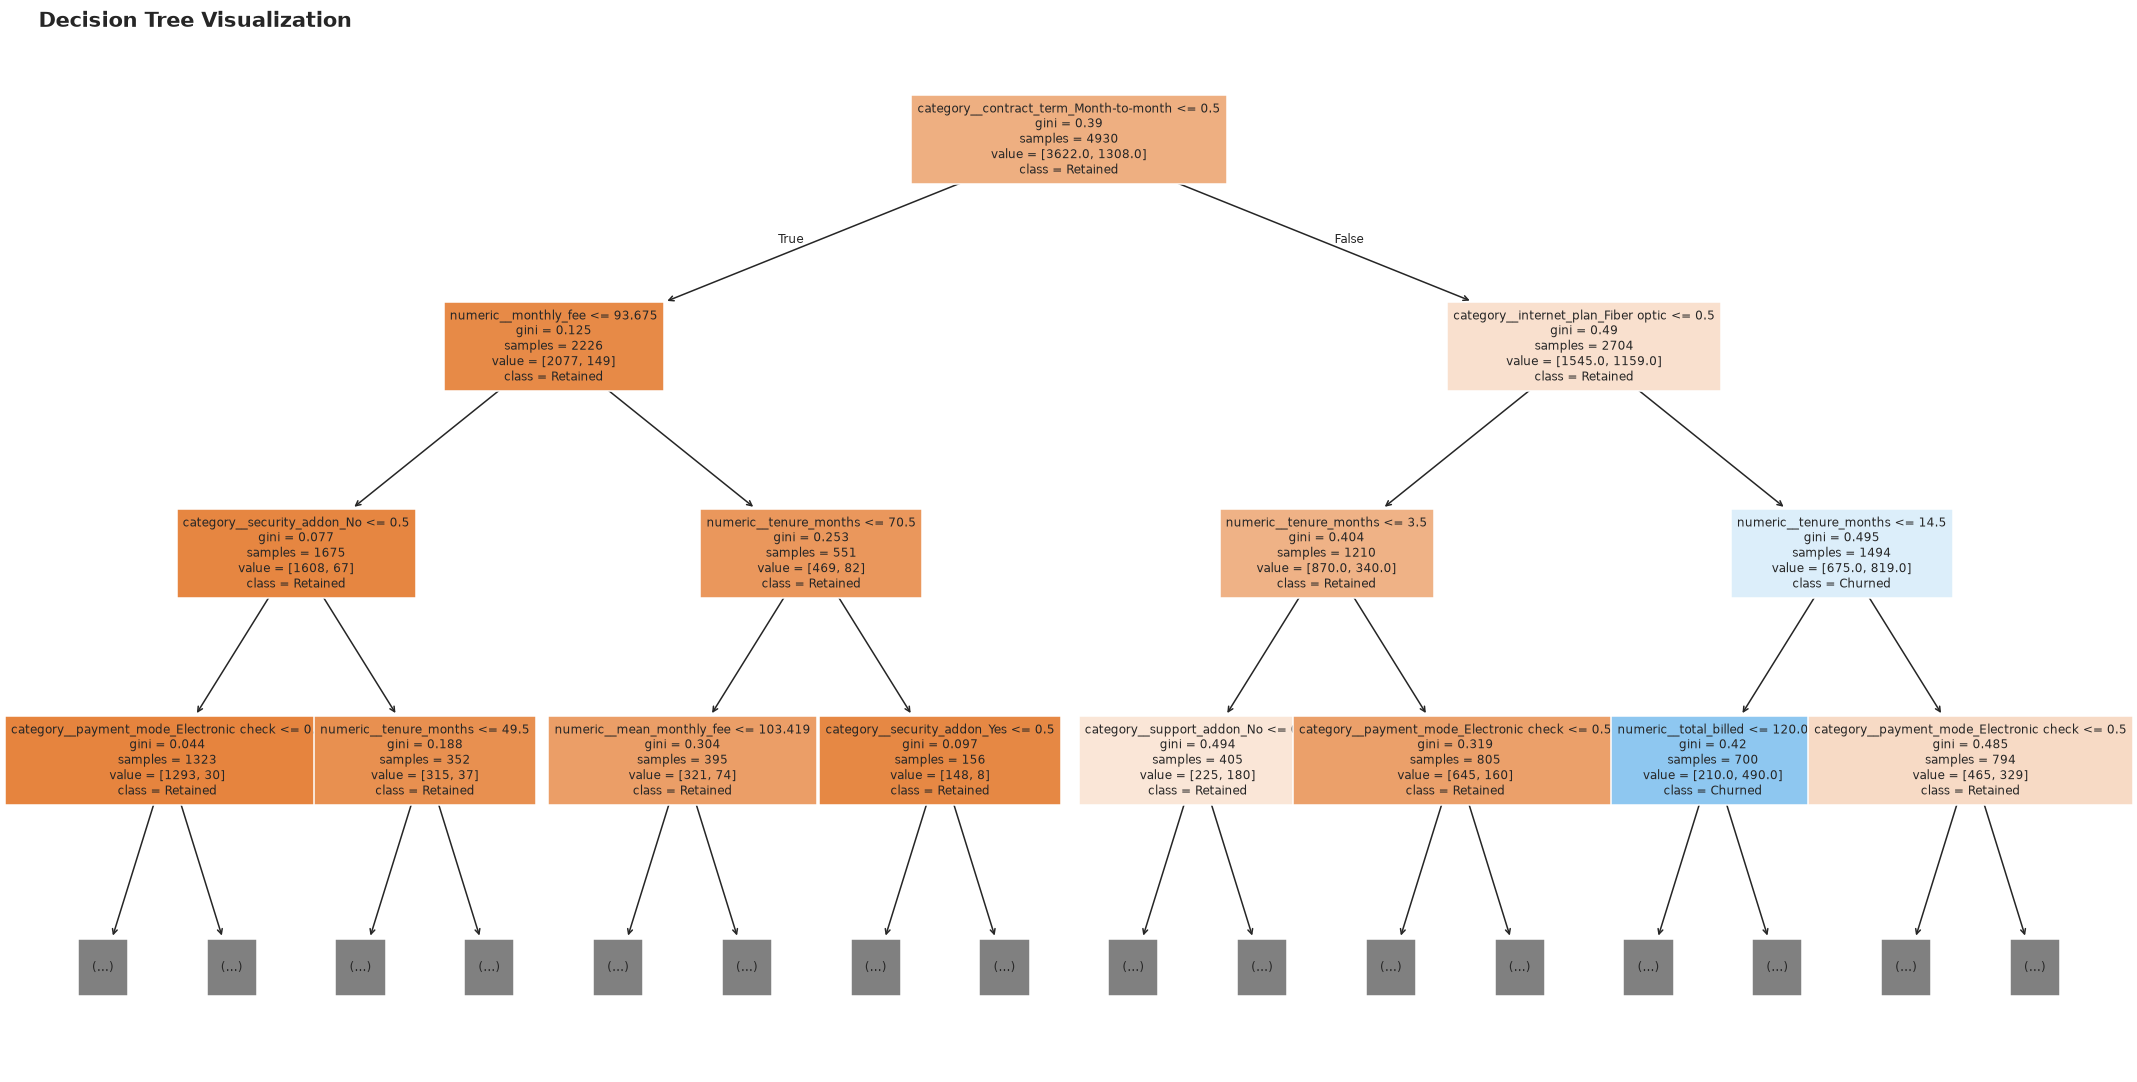

In [92]:
plt.figure(figsize=(20, 10))

plot_tree(
    tree_estimator,
    max_depth=3,
    feature_names=encoded_names,
    class_names=["Retained", "Churned"],
    filled=True,
    fontsize=8
)

plt.title("Decision Tree Visualization")
plt.tight_layout()
plt.show()

In [93]:
import joblib

In [94]:
os.makedirs("../artifacts", exist_ok=True)

joblib.dump(
    deep_pipeline,
    "../artifacts/attrition_pipeline.pkl"
)

['../artifacts/attrition_pipeline.pkl']

In [95]:
reloaded_pipeline = joblib.load("../artifacts/attrition_pipeline.pkl")

In [96]:
sample_labels = reloaded_pipeline.predict(features_test.head(5))

print(sample_labels)

[0 0 1 0 0]


In [97]:
sample_probs = reloaded_pipeline.predict_proba(features_test.head(5))

print(sample_probs)

[[0.74418605 0.25581395]
 [1.         0.        ]
 [0.37440758 0.62559242]
 [1.         0.        ]
 [1.         0.        ]]
